***I will train 2 Logistic Regression models where Model 2 accounts for the moment in time that the pass is made during the match, and Model 1 doesn't***

In [204]:
import pandas as pd

df = pd.read_csv('../data/processed/processed_passes.csv')

df.columns

Index(['match_id', 'period', 'half_percentage', 'net_score', 'under_pressure',
       'start_x', 'start_y', 'end_x', 'end_y', 'pass_angle', 'pass_length',
       'dist_to_goal', 'is_progressive', 'height_Low Pass', 'height_High Pass',
       'body_part_Foot', 'body_part_Head', 'body_part_Keeper Arm',
       'play_pattern_Regular Play', 'play_pattern_Kick Off',
       'play_pattern_Throw In', 'play_pattern_Free Kick',
       'play_pattern_Goal Kick', 'play_pattern_Keeper', 'play_pattern_Corner',
       'pass_outcome'],
      dtype='str')

In [205]:
features1 = [ 
    'under_pressure',
    'start_x', 
    'start_y', 
    'end_x', 
    'end_y', 
    'pass_angle', 
    'pass_length',
    'dist_to_goal'
]

In [206]:
features2 = [
    'period', 
    'half_percentage', 
    'net_score', 
    'under_pressure',
    'start_x', 
    'start_y', 
    'end_x', 
    'end_y', 
    'pass_angle', 
    'pass_length',
    'dist_to_goal'
]

In [207]:
features3 = [ 
    'under_pressure',
    'start_x', 
    'start_y', 
    'end_x', 
    'end_y', 
    'pass_angle', 
    'pass_length',
    'dist_to_goal', 
    'is_progressive'
]

In [208]:
def train_xgb(features):

    print('Splitting the data...')

    X = df[features]
    y = df['pass_outcome']

    from sklearn.model_selection import train_test_split
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

    print(f"Training Passes: {len(X_train)} passes")
    print(f"Testing Passes: {len(X_test)} passes")

    import xgboost as xgb

    # Specify the parameters of my models
    xgb_config = {
        'n_estimators': 100,
        'max_depth': 4,
        'learning_rate': 0.05,
        'subsample': 0.8,
        'colsample_bytree': 0.8,
        'random_state': 42,
        'eval_metric': 'logloss'
    }

    xgb1 = xgb.XGBClassifier(**xgb_config)
    




In [209]:
X1 = df[features1]
y = df['pass_outcome']

In [210]:
X2 = df[features2]
X3 = df[features3]

In [211]:
# Divide my data to training and test with an 80% to 20% split respectively
from sklearn.model_selection import train_test_split
X_train1, X_test1, y_train1, y_test1 = train_test_split(X1, y, test_size = 0.2, random_state = 42)

In [212]:
X_train2, X_test2, y_train2, y_test2 = train_test_split(X2, y, test_size = 0.2, random_state = 42)
X_train3, X_test3, y_train3, y_test3 = train_test_split(X3, y, test_size = 0.2, random_state = 42)

In [213]:
print(f"Training Passes: {len(X_train1)} passes")
print(f"Testing Passes: {len(X_test1)} passes")

Training Passes: 32269 passes
Testing Passes: 8068 passes


In [214]:
# Prevent jupyter notebook html display errors
import sklearn
sklearn.set_config(display="text")

In [215]:
# Firstly I will train a Logistic Regression model

from sklearn.linear_model import LogisticRegression

log_reg_model1 = LogisticRegression(max_iter=1000)
log_reg_model1.fit(X_train1, y_train1)

LogisticRegression(max_iter=1000)

In [216]:
from sklearn.linear_model import LogisticRegression

log_reg_model2 = LogisticRegression(max_iter=1000)
log_reg_model2.fit(X_train2, y_train2)

LogisticRegression(max_iter=1000)

In [217]:
from sklearn.metrics import accuracy_score

log_reg_train_predictions1 = log_reg_model1.predict(X_train1)
log_reg_test_predictions1 = log_reg_model1.predict(X_test1)

print(f"Training Accuracy for Model 1: {accuracy_score(y_train1, log_reg_train_predictions1)*100:.4f} %")
print(f"Testing Accuracy for Model 1: {accuracy_score(y_test1, log_reg_test_predictions1)*100:.4f} %")

Training Accuracy for Model 1: 86.8233 %
Testing Accuracy for Model 1: 86.5394 %


In [218]:
from sklearn.metrics import accuracy_score

log_reg_train_predictions2 = log_reg_model2.predict(X_train2)
log_reg_test_predictions2 = log_reg_model2.predict(X_test2)

print(f"Training Accuracy for Model 2: {accuracy_score(y_train2, log_reg_train_predictions2)*100:.4f} %")
print(f"Testing Accuracy for Model 2: {accuracy_score(y_test2, log_reg_test_predictions2)*100:.4f} %")

Training Accuracy for Model 2: 86.8481 %
Testing Accuracy for Model 2: 86.5518 %


In [219]:
#Calculate Probabilistic Metrics for Model 1

from sklearn.metrics import log_loss, brier_score_loss, roc_auc_score

log_reg_y_prob1 = log_reg_model1.predict_proba(X_test1)[:, 1]

log_reg_baseline_log_loss1 = log_loss(y_test1, log_reg_y_prob1)
log_reg_baseline_brier1 = brier_score_loss(y_test1, log_reg_y_prob1)
log_reg_baseline_auc1 = roc_auc_score(y_test1, log_reg_y_prob1)

print(f"Baseline Log-Loss for Model 1: {log_reg_baseline_log_loss1:.5f}")
print(f"Baseline Brier Score for Model 1: {log_reg_baseline_brier1:.5f}")
print(f"Baseline ROC-AUC for Model 1: {log_reg_baseline_auc1:.5f}")

Baseline Log-Loss for Model 1: 0.33189
Baseline Brier Score for Model 1: 0.10045
Baseline ROC-AUC for Model 1: 0.79985


In [220]:
#Calculate Probabilistic Metrics for Model 2

from sklearn.metrics import log_loss, brier_score_loss, roc_auc_score

log_reg_y_prob2 = log_reg_model2.predict_proba(X_test2)[:, 1]

log_reg_baseline_log_loss2 = log_loss(y_test2, log_reg_y_prob2)
log_reg_baseline_brier2 = brier_score_loss(y_test2, log_reg_y_prob2)
log_reg_baseline_auc2 = roc_auc_score(y_test2, log_reg_y_prob2)

print(f"Baseline Log-Loss for Model 2: {log_reg_baseline_log_loss2:.5f}")
print(f"Baseline Brier Score for Model 2: {log_reg_baseline_brier2:.5f}")
print(f"Baseline ROC-AUC for Model 2: {log_reg_baseline_auc2:.5f}")

Baseline Log-Loss for Model 2: 0.33180
Baseline Brier Score for Model 2: 0.10049
Baseline ROC-AUC for Model 2: 0.80020


***I will now train and compare in a similar way Models with different features using XGBOOST***

In [221]:
def train_xgb(features):

    print('Splitting the data...')

    X = df[features]
    y = df['pass_outcome']

    from sklearn.model_selection import train_test_split
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

    print(f"Training Passes: {len(X_train)} passes")
    print(f"Testing Passes: {len(X_test)} passes")

    print('\nTraining XGBOOST Model ...')
    import xgboost as xgb

    # Specify the parameters of my models
    xgb_config = {
        'n_estimators': 100,
        'max_depth': 4,
        'learning_rate': 0.05,
        'subsample': 0.8,
        'colsample_bytree': 0.8,
        'random_state': 42,
        'eval_metric': 'logloss'
    }

    xgb_current = xgb.XGBClassifier(**xgb_config)


    xgb_current.fit(X_train, y_train)
    print('XGBOOST Model training Done!')

    from sklearn.metrics import accuracy_score
    xgb_train_predictions = xgb_current.predict(X_train)
    xgb_test_predictions = xgb_current.predict(X_test)
    print(f"\nTraining Accuracy for XGBOOST Model: {accuracy_score(y_train, xgb_train_predictions)*100:.4f} %")
    print(f"Testing Accuracy for XGBOOST Model: {accuracy_score(y_test, xgb_test_predictions)*100:.4f} %")  

    #Calculate Probabilistic Metrics for XGBOOST Model (Basic Metrics)
    
    from sklearn.metrics import log_loss, brier_score_loss, roc_auc_score
    xgb_y_prob = xgb_current.predict_proba(X_test)[:, 1]

    xgb_baseline_log_loss = log_loss(y_test, xgb_y_prob)
    xgb_baseline_brier = brier_score_loss(y_test, xgb_y_prob)
    xgb_baseline_auc = roc_auc_score(y_test, xgb_y_prob)

    print(f"\nBaseline Log-Loss for XGBOOST Model: {xgb_baseline_log_loss:.5f}")
    print(f"Baseline Brier Score for XGBOOST Model: {xgb_baseline_brier:.5f}")
    print(f"Baseline ROC-AUC for XGBOOST Model: {xgb_baseline_auc:.5f}")

    return xgb_current

In [222]:
df.columns

Index(['match_id', 'period', 'half_percentage', 'net_score', 'under_pressure',
       'start_x', 'start_y', 'end_x', 'end_y', 'pass_angle', 'pass_length',
       'dist_to_goal', 'is_progressive', 'height_Low Pass', 'height_High Pass',
       'body_part_Foot', 'body_part_Head', 'body_part_Keeper Arm',
       'play_pattern_Regular Play', 'play_pattern_Kick Off',
       'play_pattern_Throw In', 'play_pattern_Free Kick',
       'play_pattern_Goal Kick', 'play_pattern_Keeper', 'play_pattern_Corner',
       'pass_outcome'],
      dtype='str')

In [223]:
feat1 = [
    'period', 'half_percentage', 'net_score', 'under_pressure',
       'start_x', 'start_y', 'end_x', 'end_y', 'pass_angle', 'pass_length',
       'dist_to_goal', 'is_progressive'
]

print('---SPATIAL + TEMPORAL/SCORELINE + PROGRESSIVE---\n')
xgb1 = train_xgb(feat1)

---SPATIAL + TEMPORAL/SCORELINE + PROGRESSIVE---

Splitting the data...
Training Passes: 32269 passes
Testing Passes: 8068 passes

Training XGBOOST Model ...


XGBOOST Model training Done!

Training Accuracy for XGBOOST Model: 90.4335 %
Testing Accuracy for XGBOOST Model: 89.8860 %

Baseline Log-Loss for XGBOOST Model: 0.26619
Baseline Brier Score for XGBOOST Model: 0.07828
Baseline ROC-AUC for XGBOOST Model: 0.88408


In [224]:
feat2 = [
    'period', 'half_percentage', 'net_score', 'under_pressure',
       'start_x', 'start_y', 'end_x', 'end_y', 'pass_angle', 'pass_length',
       'dist_to_goal'
]

print('---SPATIAL + TEMPORAL/SCORELINE---\n')
xgb2 = train_xgb(feat2)

---SPATIAL + TEMPORAL/SCORELINE---

Splitting the data...
Training Passes: 32269 passes
Testing Passes: 8068 passes

Training XGBOOST Model ...
XGBOOST Model training Done!

Training Accuracy for XGBOOST Model: 90.4738 %
Testing Accuracy for XGBOOST Model: 89.8612 %

Baseline Log-Loss for XGBOOST Model: 0.26652
Baseline Brier Score for XGBOOST Model: 0.07840
Baseline ROC-AUC for XGBOOST Model: 0.88368


In [225]:
feat3 = [
    'under_pressure',
       'start_x', 'start_y', 'end_x', 'end_y', 'pass_angle', 'pass_length',
       'dist_to_goal', 'is_progressive'
]

print('---SPATIAL + PROGRESSIVE---\n')
xgb3 = train_xgb(feat3)

---SPATIAL + PROGRESSIVE---

Splitting the data...
Training Passes: 32269 passes
Testing Passes: 8068 passes

Training XGBOOST Model ...
XGBOOST Model training Done!

Training Accuracy for XGBOOST Model: 90.4149 %
Testing Accuracy for XGBOOST Model: 89.8240 %

Baseline Log-Loss for XGBOOST Model: 0.26537
Baseline Brier Score for XGBOOST Model: 0.07807
Baseline ROC-AUC for XGBOOST Model: 0.88556


In [226]:
feat4 = [
    'under_pressure',
       'start_x', 'start_y', 'end_x', 'end_y', 'pass_angle', 'pass_length',
       'dist_to_goal'
]

print('---SPATIAL---\n')
xgb4 = train_xgb(feat4)

---SPATIAL---

Splitting the data...
Training Passes: 32269 passes
Testing Passes: 8068 passes

Training XGBOOST Model ...
XGBOOST Model training Done!

Training Accuracy for XGBOOST Model: 90.4366 %
Testing Accuracy for XGBOOST Model: 89.8736 %

Baseline Log-Loss for XGBOOST Model: 0.26581
Baseline Brier Score for XGBOOST Model: 0.07810
Baseline ROC-AUC for XGBOOST Model: 0.88386


In [227]:
feat5 = [
       'start_x', 'start_y', 'end_x', 'end_y', 'pass_angle', 'pass_length',
       'dist_to_goal'
]

print('---SPATIAL EXCLUDING UNDER PRESSURE---\n')
xgb5 = train_xgb(feat5)

---SPATIAL EXCLUDING UNDER PRESSURE---

Splitting the data...
Training Passes: 32269 passes
Testing Passes: 8068 passes

Training XGBOOST Model ...


XGBOOST Model training Done!

Training Accuracy for XGBOOST Model: 90.3778 %
Testing Accuracy for XGBOOST Model: 89.8240 %

Baseline Log-Loss for XGBOOST Model: 0.26994
Baseline Brier Score for XGBOOST Model: 0.07909
Baseline ROC-AUC for XGBOOST Model: 0.87687


In [228]:
feat6 = [
       'start_x', 'start_y', 'end_x', 'end_y', 'pass_angle', 'pass_length',
       'dist_to_goal', 'is_progressive'
]

print('---SPATIAL + PROGRESSIVE EXCLUDING UNDER PRESSURE---\n')
xgb6 = train_xgb(feat6)

---SPATIAL + PROGRESSIVE EXCLUDING UNDER PRESSURE---

Splitting the data...
Training Passes: 32269 passes
Testing Passes: 8068 passes

Training XGBOOST Model ...
XGBOOST Model training Done!

Training Accuracy for XGBOOST Model: 90.3809 %
Testing Accuracy for XGBOOST Model: 89.6629 %

Baseline Log-Loss for XGBOOST Model: 0.26922
Baseline Brier Score for XGBOOST Model: 0.07890
Baseline ROC-AUC for XGBOOST Model: 0.87754


In [229]:
feat7 = [
       'start_x', 'start_y', 'end_x', 'end_y', 'pass_angle', 'pass_length',
       'dist_to_goal', 'is_progressive', 'height_Low Pass', 'height_High Pass',
       'body_part_Foot', 'body_part_Head', 'body_part_Keeper Arm',
       'play_pattern_Regular Play', 'play_pattern_Kick Off',
       'play_pattern_Throw In', 'play_pattern_Free Kick',
       'play_pattern_Goal Kick', 'play_pattern_Keeper', 'play_pattern_Corner',
       'under_pressure'
]

print('---SPATIAL + PROGRESSIVE + ADDED FLAGS---\n')
xgb7 = train_xgb(feat7)

---SPATIAL + PROGRESSIVE + ADDED FLAGS---

Splitting the data...
Training Passes: 32269 passes
Testing Passes: 8068 passes

Training XGBOOST Model ...
XGBOOST Model training Done!

Training Accuracy for XGBOOST Model: 90.6970 %
Testing Accuracy for XGBOOST Model: 90.2330 %

Baseline Log-Loss for XGBOOST Model: 0.24845
Baseline Brier Score for XGBOOST Model: 0.07343
Baseline ROC-AUC for XGBOOST Model: 0.90407


In [230]:
feat8 = [
       'start_x', 'start_y', 'end_x', 'end_y', 'pass_angle', 'pass_length',
       'dist_to_goal', 'height_Low Pass', 'height_High Pass',
       'body_part_Foot', 'body_part_Head', 'body_part_Keeper Arm',
       'play_pattern_Regular Play', 'play_pattern_Kick Off',
       'play_pattern_Throw In', 'play_pattern_Free Kick',
       'play_pattern_Goal Kick', 'play_pattern_Keeper', 'play_pattern_Corner',
       'under_pressure'
]

print('---SPATIAL + ADDED FLAGS---\n')
xgb8 = train_xgb(feat8)

---SPATIAL + ADDED FLAGS---

Splitting the data...
Training Passes: 32269 passes
Testing Passes: 8068 passes

Training XGBOOST Model ...
XGBOOST Model training Done!

Training Accuracy for XGBOOST Model: 90.7961 %
Testing Accuracy for XGBOOST Model: 90.2826 %

Baseline Log-Loss for XGBOOST Model: 0.24693
Baseline Brier Score for XGBOOST Model: 0.07287
Baseline ROC-AUC for XGBOOST Model: 0.90506


In [231]:
feat9 = [
    'period', 'half_percentage', 'net_score',
       'start_x', 'start_y', 'end_x', 'end_y', 'pass_angle', 'pass_length',
       'dist_to_goal', 'height_Low Pass', 'height_High Pass',
       'body_part_Foot', 'body_part_Head', 'body_part_Keeper Arm',
       'play_pattern_Regular Play', 'play_pattern_Kick Off',
       'play_pattern_Throw In', 'play_pattern_Free Kick',
       'play_pattern_Goal Kick', 'play_pattern_Keeper', 'play_pattern_Corner',
       'under_pressure'
]

print('---SPATIAL + PROGRESSIVE + TEMPORAL/SCORELINE + ADDED FLAGS---\n')
xgb9 = train_xgb(feat9)

---SPATIAL + PROGRESSIVE + TEMPORAL/SCORELINE + ADDED FLAGS---

Splitting the data...
Training Passes: 32269 passes
Testing Passes: 8068 passes

Training XGBOOST Model ...
XGBOOST Model training Done!

Training Accuracy for XGBOOST Model: 90.7682 %
Testing Accuracy for XGBOOST Model: 90.3074 %

Baseline Log-Loss for XGBOOST Model: 0.24693
Baseline Brier Score for XGBOOST Model: 0.07293
Baseline ROC-AUC for XGBOOST Model: 0.90527


In [232]:
xgb_best = xgb8
feat_best = feat8

***I realise that the pure spatial metrics, combined with the 'play_pattern', 'height' and 'body part' 'under_pressure' flag, result in the best performing model***

***I will now create a graph showing which of the features affect the model the most***

In [233]:
importance_df = pd.DataFrame({
    'Features': feat_best,
    'Importance': xgb_best.feature_importances_
})

importance_df = importance_df.sort_values('Importance', axis=0, ascending = 1)
print('-FEATURES IMPORTANCE-\n', importance_df)

-FEATURES IMPORTANCE-
                      Features  Importance
17        play_pattern_Keeper    0.000000
13      play_pattern_Kick Off    0.001998
16     play_pattern_Goal Kick    0.005422
14      play_pattern_Throw In    0.005994
9              body_part_Foot    0.006197
18        play_pattern_Corner    0.008712
15     play_pattern_Free Kick    0.010671
12  play_pattern_Regular Play    0.011307
1                     start_y    0.011859
0                     start_x    0.015161
11       body_part_Keeper Arm    0.016372
10             body_part_Head    0.023214
3                       end_y    0.028111
19             under_pressure    0.030043
6                dist_to_goal    0.030585
4                  pass_angle    0.041850
2                       end_x    0.069405
5                 pass_length    0.080678
7             height_Low Pass    0.084252
8            height_High Pass    0.518168


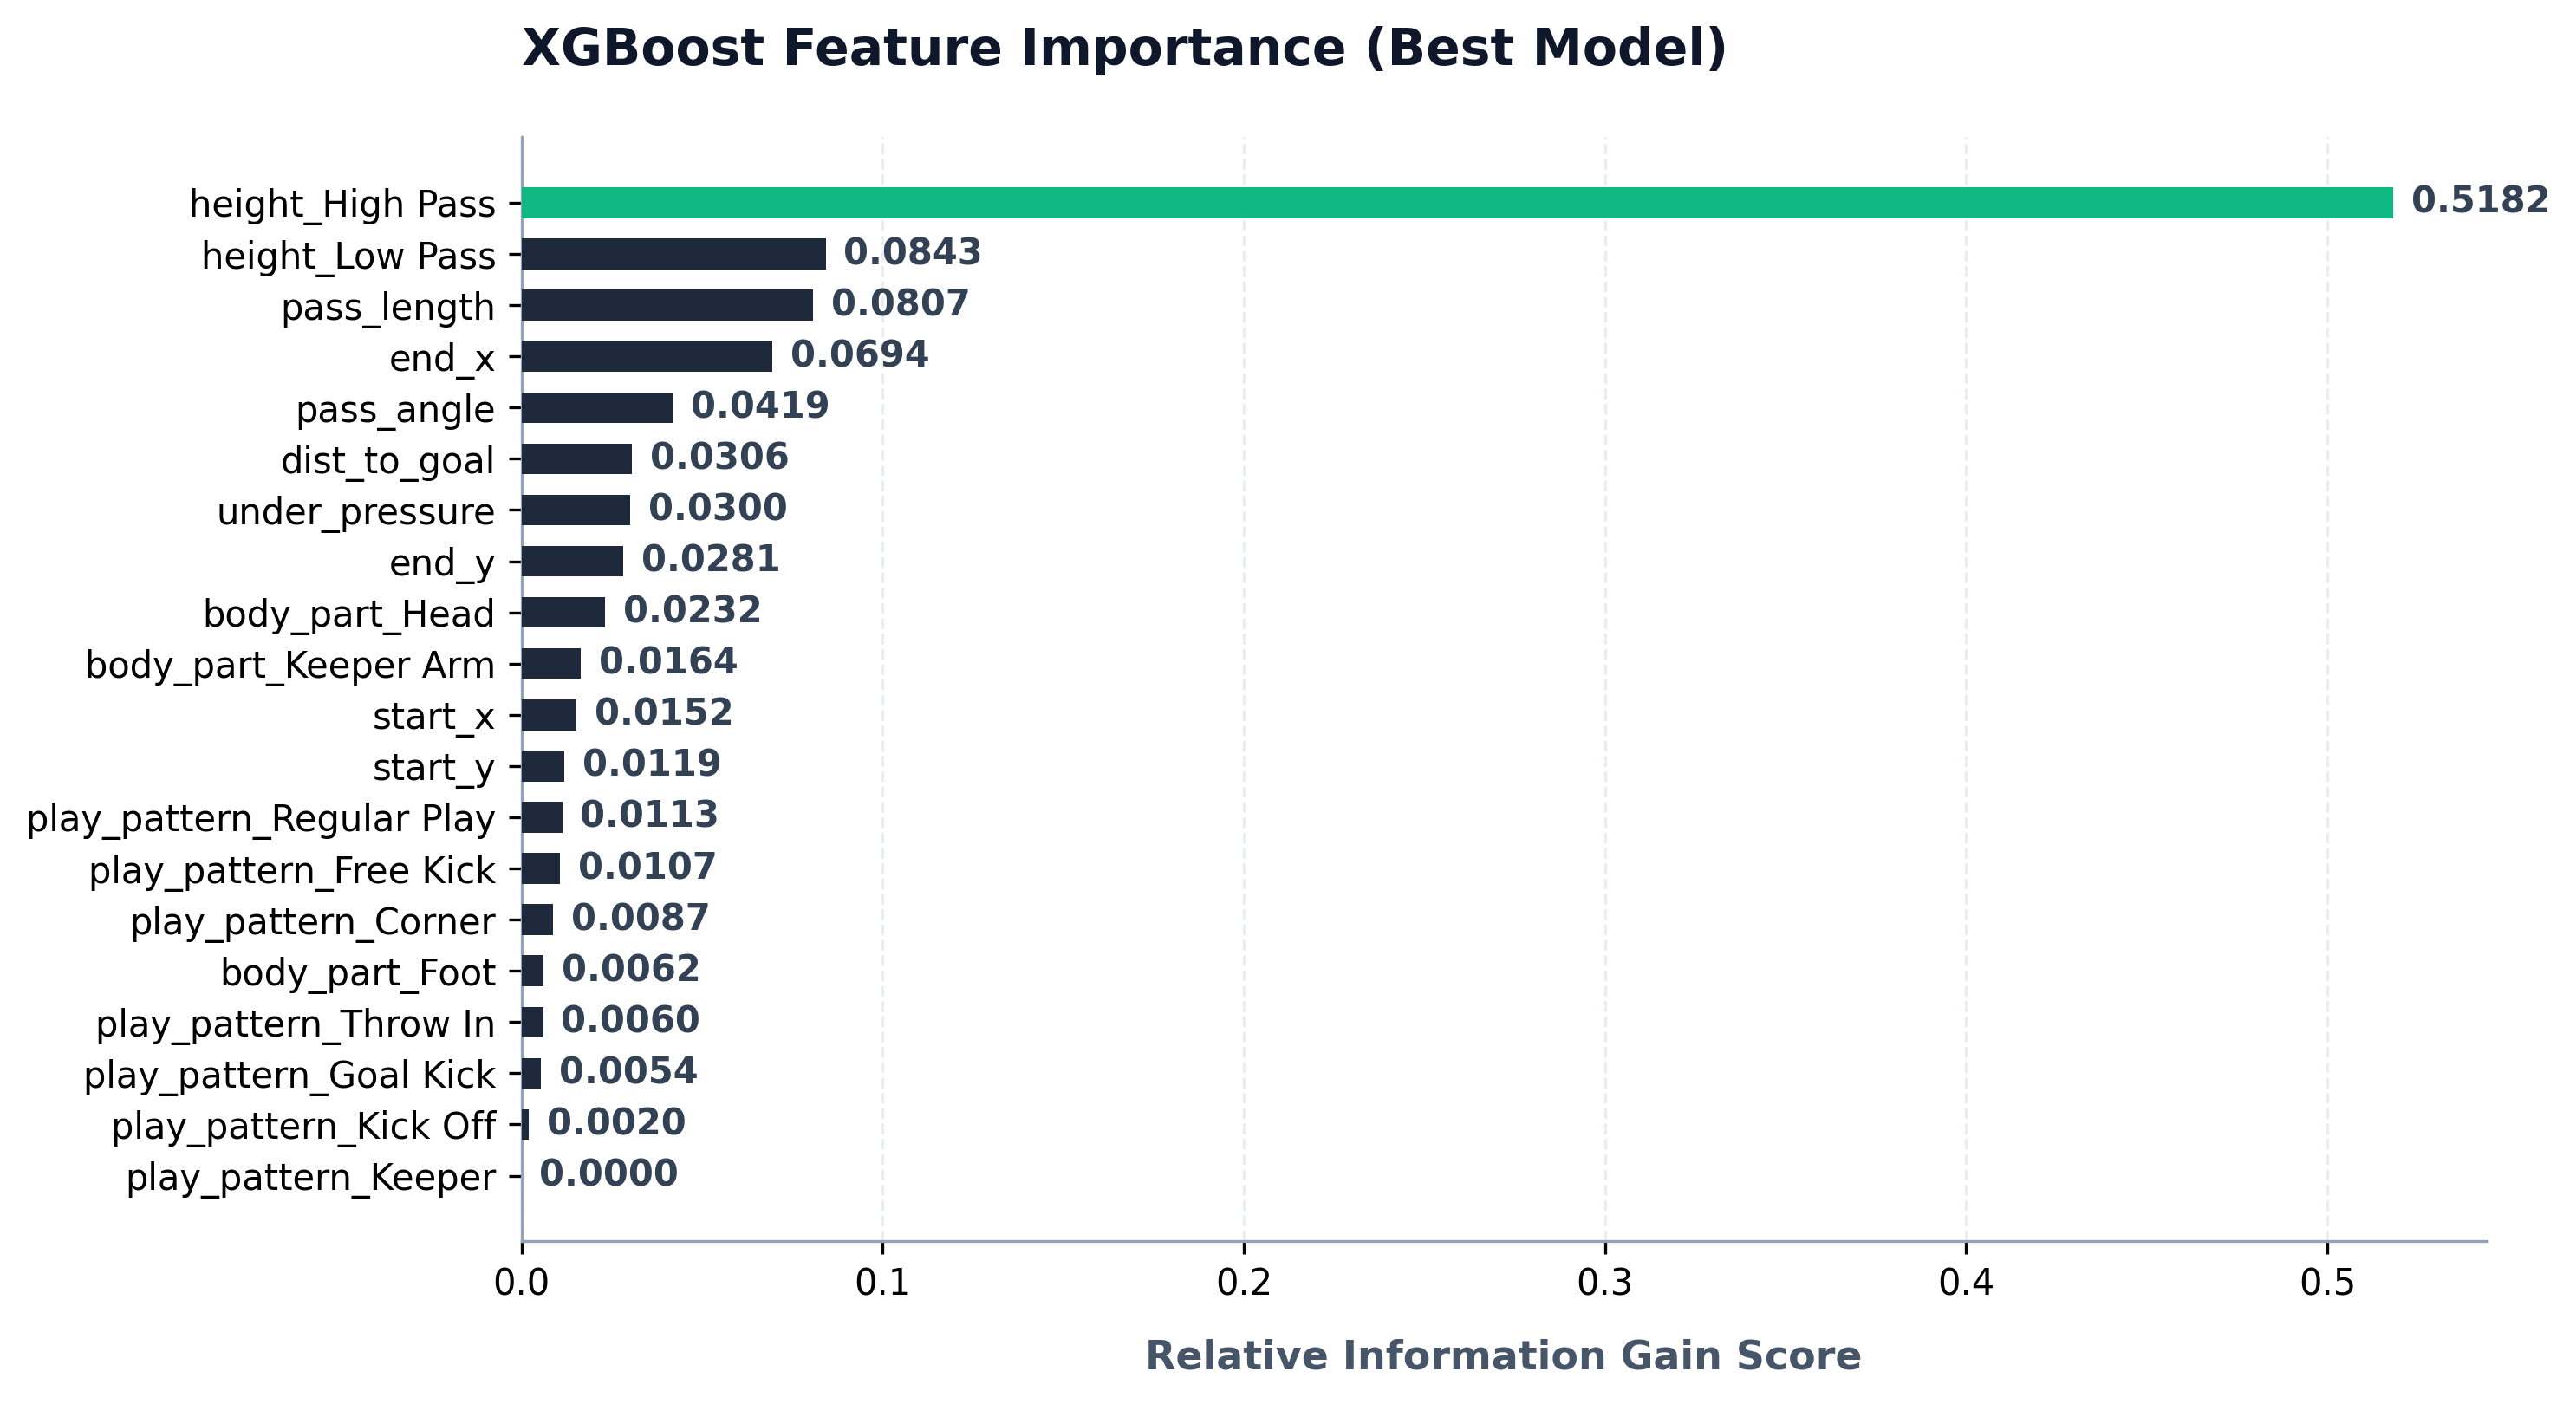

In [234]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(10, 5.5), dpi=300)

# 1. Ορισμός χρωμάτων για επαγγελματικό design
bar_color = '#1e293b'       # Σκούρο γκρι/μπλε (Slate) για όλες τις μπάρες
top_bar_color = '#10b981'   # Καθαρό σμαραγδί (Emerald Green) για το #1 χαρακτηριστικό

# Δημιουργούμε μια λίστα χρωμάτων όπου όλα είναι Slate, εκτός από το τελευταίο (το κορυφαίο) που είναι Emerald
colors = [bar_color] * (len(importance_df) - 1) + [top_bar_color]

# 2. Σχεδίαση των οριζόντιων μπαρών
bars = ax.barh(
    importance_df['Features'], 
    importance_df['Importance'], 
    color=colors, 
    height=0.6,
    zorder=3
)

# 3. Προσθήκη διακριτικού Grid (πλέγματος) στον άξονα Χ
ax.grid(axis='x', linestyle='--', alpha=0.4, color='#cbd5e1', zorder=0)

# 4. Αφαίρεση των περιττών πλαισίων (Spines) για καθαρό UI
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#94a3b8')
ax.spines['bottom'].set_color('#94a3b8')

# 5. Προσθήκη των αριθμητικών τιμών Gain στην άκρη κάθε μπάρας
for bar in bars:
    width = bar.get_width()
    ax.text(
        width + 0.005, 
        bar.get_y() + bar.get_height()/2, 
        f"{width:.4f}", 
        va='center', 
        ha='left', 
        fontsize=10, 
        weight='bold',
        color='#334155'
    )

# 6. Τίτλοι και ονομασίες αξόνων
ax.set_title(
    "XGBoost Feature Importance (Best Model)", 
    fontsize=14, 
    weight='bold', 
    pad=20, 
    color='#0f172a',
    loc='left'
)
ax.set_xlabel("Relative Information Gain Score", fontsize=11, weight='bold', color='#475569', labelpad=10)

plt.tight_layout()
plt.show()

In [235]:
# Check spatial/categorical collinearity
redundancy_matrix = df[['height_High Pass', 'pass_length', 'body_part_Head']].corr()
print("--- Collinearity Matrix ---")
print(redundancy_matrix)

--- Collinearity Matrix ---
                  height_High Pass  pass_length  body_part_Head
height_High Pass          1.000000     0.548454        0.173697
pass_length               0.548454     1.000000       -0.049602
body_part_Head            0.173697    -0.049602        1.000000


***I will now compute the true marginal feature importance using SHAP to correct for built-in Gain bias***

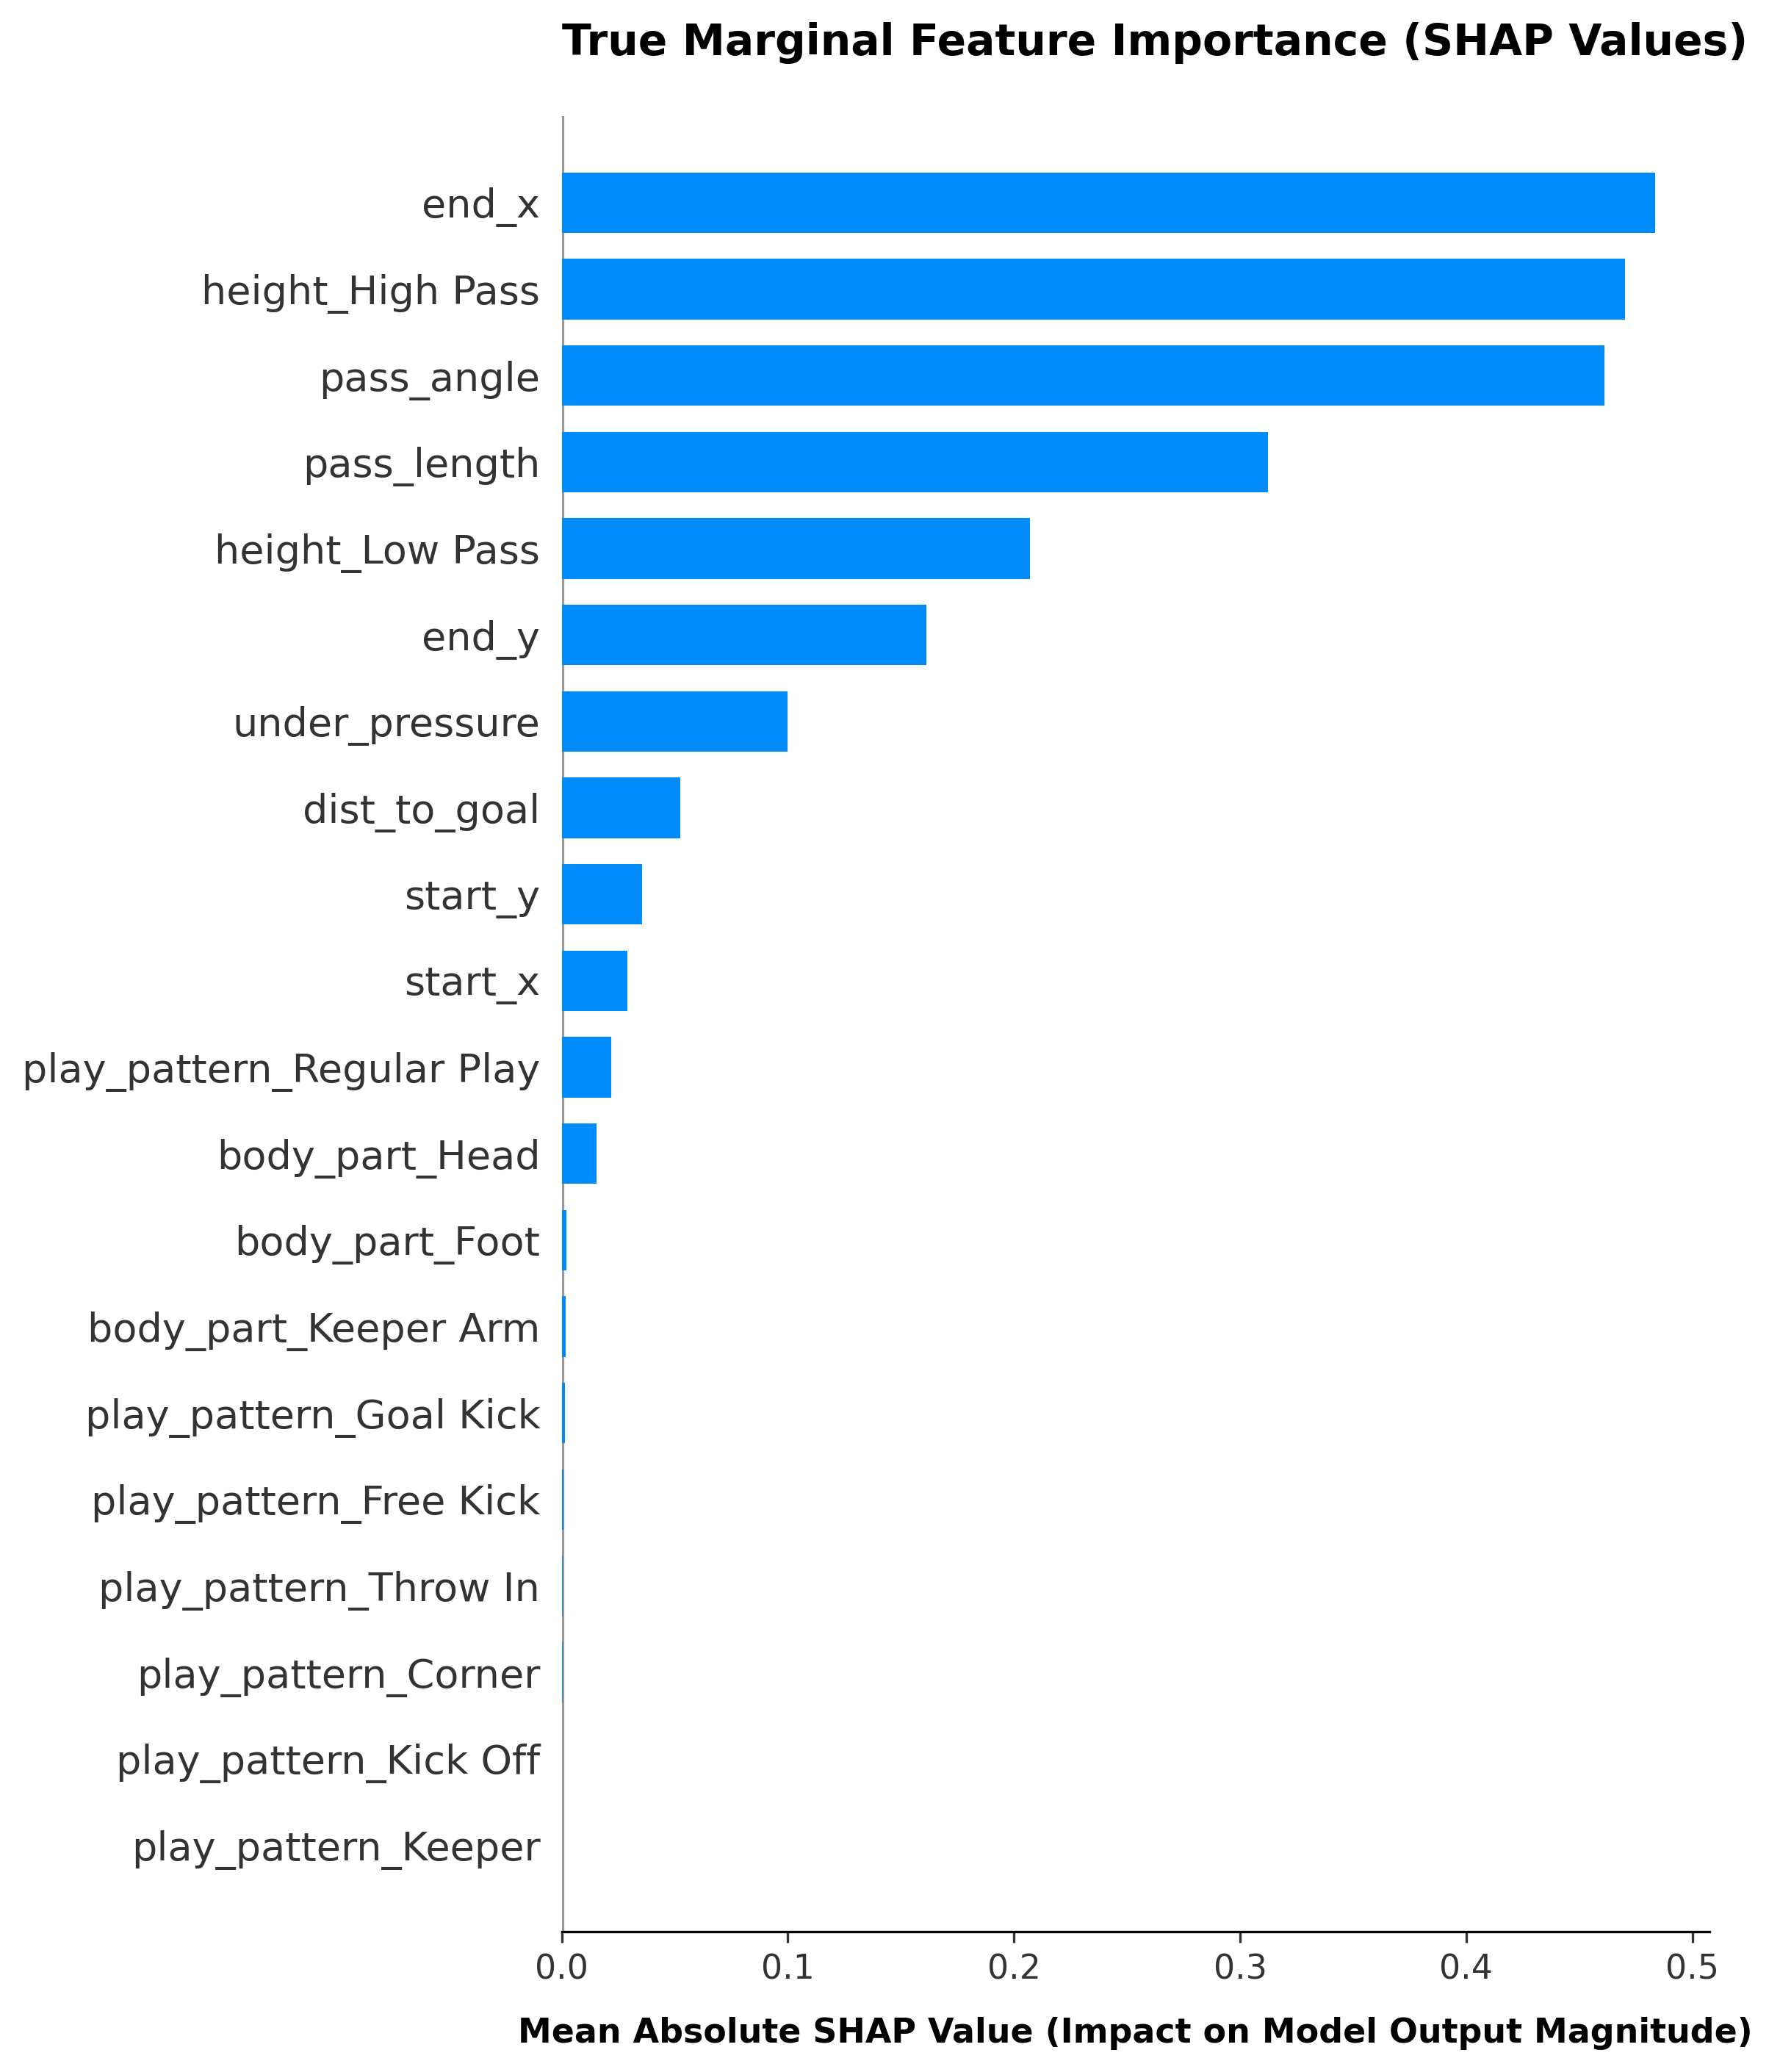

In [236]:
import shap
import matplotlib.pyplot as plt

# 1. Reconstruct the global feature matrices matching your champion model configuration (feat8)
X_best = df[feat_best]
y_best = df['pass_outcome']

# 2. Re-execute the identical 80/20 train/test split to perfectly match the training state
from sklearn.model_selection import train_test_split
_, X_test_best, _, _ = train_test_split(X_best, y_best, test_size=0.2, random_state=42)

# 3. Initialize the TreeExplainer with your champion model
explainer = shap.TreeExplainer(xgb_best)

# 4. Compute the true Shapley marginal contributions over the test slice
shap_values = explainer(X_test_best)

# 5. Generate the authentic SHAP Feature Importance Summary Plot
plt.figure(figsize=(10, 6), dpi=300)
shap.summary_plot(shap_values, X_test_best, plot_type="bar", show=False)

# Clean up styling to match your slate-design theme
plt.title("True Marginal Feature Importance (SHAP Values)", fontsize=14, weight='bold', pad=20, loc='left')
plt.xlabel("Mean Absolute SHAP Value (Impact on Model Output Magnitude)", fontsize=11, weight='bold', labelpad=10)
plt.tight_layout()
plt.show()

In [237]:
# 1. Calculate the mean absolute SHAP value for each feature column
mean_abs_shap = np.abs(shap_values.values).mean(axis=0)

# 2. Build a clean, sorted Pandas DataFrame
shap_importance_df = pd.DataFrame({
    'Features': X_test_best.columns,
    'Mean Abs SHAP Value': mean_abs_shap
})

# 3. Sort descending so the most influential tactical features are at the top
shap_importance_df = shap_importance_df.sort_values(by='Mean Abs SHAP Value', ascending=False).reset_index(drop=True)

# 4. Display the clean text table
print("- TRUE MARGINAL IMPORTANCE (SHAP TABLE) -")
print(shap_importance_df.to_string(index=True, formatters={'Mean Abs SHAP Value': '{:,.6f}'.format}))

- TRUE MARGINAL IMPORTANCE (SHAP TABLE) -
                     Features Mean Abs SHAP Value
0                       end_x            0.483415
1            height_High Pass            0.470094
2                  pass_angle            0.461113
3                 pass_length            0.312512
4             height_Low Pass            0.207004
5                       end_y            0.161190
6              under_pressure            0.099838
7                dist_to_goal            0.052324
8                     start_y            0.035719
9                     start_x            0.029187
10  play_pattern_Regular Play            0.022018
11             body_part_Head            0.015377
12             body_part_Foot            0.002117
13       body_part_Keeper Arm            0.001888
14     play_pattern_Goal Kick            0.001481
15     play_pattern_Free Kick            0.000785
16      play_pattern_Throw In            0.000384
17        play_pattern_Corner            0.000378
18      

In [238]:
feat_withoutendcoor = [feature for feature in feat_best if feature not in ['end_x', 'end_y']]
xgb_withoutendcoor = train_xgb(feat_withoutendcoor)

Splitting the data...
Training Passes: 32269 passes
Testing Passes: 8068 passes

Training XGBOOST Model ...
XGBOOST Model training Done!

Training Accuracy for XGBOOST Model: 90.1329 %
Testing Accuracy for XGBOOST Model: 89.5265 %

Baseline Log-Loss for XGBOOST Model: 0.26066
Baseline Brier Score for XGBOOST Model: 0.07758
Baseline ROC-AUC for XGBOOST Model: 0.89236


In [244]:
feat_withoutendcoorandlength = [feature for feature in feat_best if feature not in ['end_x', 'end_y', 'pass_length']]
xgb_withoutendcoorandlength = train_xgb(feat_withoutendcoorandlength)

Splitting the data...
Training Passes: 32269 passes
Testing Passes: 8068 passes

Training XGBOOST Model ...
XGBOOST Model training Done!

Training Accuracy for XGBOOST Model: 89.1351 %
Testing Accuracy for XGBOOST Model: 88.5226 %

Baseline Log-Loss for XGBOOST Model: 0.27757
Baseline Brier Score for XGBOOST Model: 0.08287
Baseline ROC-AUC for XGBOOST Model: 0.87389


In [240]:
x = train_xgb(feat_best)

Splitting the data...
Training Passes: 32269 passes
Testing Passes: 8068 passes

Training XGBOOST Model ...
XGBOOST Model training Done!

Training Accuracy for XGBOOST Model: 90.7961 %
Testing Accuracy for XGBOOST Model: 90.2826 %

Baseline Log-Loss for XGBOOST Model: 0.24693
Baseline Brier Score for XGBOOST Model: 0.07287
Baseline ROC-AUC for XGBOOST Model: 0.90506


***Because the improvement in performace when including the end coordinates is minimal, there is no real reason to include them in the features of the model.***

***When removing pass length the difference appears more important but not enough to excuse the danger in data leakage***

***This way we avoid any possible data leakage that might have been caused as the ending coordinates when a pass is not completed do not represent the ending destination that the player performing the pass might have intended.***

In [245]:
xgb_truebest = xgb_withoutendcoorandlength
feat_truebest = feat_withoutendcoorandlength